<a href="https://colab.research.google.com/github/Nrnsaaaa/Kriptografi/blob/main/UTS_Soal_D_20123063.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Soal 1 vigenere encrypt
pt = "SECURITYISPRIORITY"
key = "LEMON"
alpha = {c:i for i,c in enumerate("ABCDEFGHIJKLMNOPQRSTUVWXYZ")}
def vigenere_encrypt(pt,key):
    kseq = (key * ((len(pt)//len(key))+1))[:len(pt)]
    cipher=""
    table=[]
    for p,k in zip(pt,kseq):
        P = alpha[p]; K = alpha[k]
        Cnum = (P+K)%26
        C = "ABCDEFGHIJKLMNOPQRSTUVWXYZ"[Cnum]
        table.append((p,P,k,K,P+K,Cnum,C))
        cipher += C
    return cipher,table
cipher,table = vigenere_encrypt(pt,key)
print(cipher)

DIOIETXKWFAVUCETXK


In [2]:
# Soal 2 Deskripsi Playfair
import pandas as pd

# Fungsi membangun matriks Playfair 5x5
def build_playfair_matrix(key):
    key = key.upper().replace('J', 'I')
    seen = set()
    matrix = []
    for char in key + 'ABCDEFGHIKLMNOPQRSTUVWXYZ':
        if char not in seen:
            seen.add(char)
            matrix.append(char)
    return [matrix[i:i+5] for i in range(0, 25, 5)]

# Fungsi cari posisi huruf dalam matriks
def find_position(matrix, char):
    for i, row in enumerate(matrix):
        if char in row:
            return i, row.index(char)
    return None

# Fungsi pecah ciphertext jadi digraf
def split_digraphs(text):
    text = text.upper().replace('J', 'I')
    return [text[i:i+2] for i in range(0, len(text), 2)]

# Fungsi dekripsi per aturan Playfair
def decrypt_playfair(ciphertext, key):
    matrix = build_playfair_matrix(key)
    digraphs = split_digraphs(ciphertext)
    plaintext = ''
    steps = []

    for pair in digraphs:
        a, b = pair[0], pair[1]
        row_a, col_a = find_position(matrix, a)
        row_b, col_b = find_position(matrix, b)

        if row_a == row_b:
            # Baris sama → geser kiri
            new_a = matrix[row_a][(col_a - 1) % 5]
            new_b = matrix[row_b][(col_b - 1) % 5]
        elif col_a == col_b:
            # Kolom sama → geser atas
            new_a = matrix[(row_a - 1) % 5][col_a]
            new_b = matrix[(row_b - 1) % 5][col_b]
        else:
            # Persegi → tukar kolom
            new_a = matrix[row_a][col_b]
            new_b = matrix[row_b][col_a]

        plaintext += new_a + new_b
        steps.append([pair, new_a + new_b, f"{a}({row_a},{col_a}) ↔ {b}({row_b},{col_b})"])

    return plaintext, steps, matrix

# ===== Input Soal =====
ciphertext = "GATLMZCLRQXX"
key = "MONARCHY"

# Jalankan dekripsi
plaintext, steps, matrix = decrypt_playfair(ciphertext, key)

# Tampilkan hasil
print("=== Matriks Playfair ===")
for row in matrix:
    print(' '.join(row))

print("\n=== Digraf dan Hasil Dekripsi ===")
df = pd.DataFrame(steps, columns=["Digraf", "Plaintext", "Posisi"])
display(df)

print(f"\nPlaintext akhir: {plaintext}")

=== Matriks Playfair ===
M O N A R
C H Y B D
E F G I K
L P Q S T
U V W X Z

=== Digraf dan Hasil Dekripsi ===


,Digraf,Plaintext,Posisi
0,GA,IN,"G(2,2) ↔ A(0,3)"
1,TL,ST,"T(3,4) ↔ L(3,0)"
2,MZ,RU,"M(0,0) ↔ Z(4,4)"
3,CL,ME,"C(1,0) ↔ L(3,0)"
4,RQ,NT,"R(0,4) ↔ Q(3,2)"
5,XX,WW,"X(4,3) ↔ X(4,3)"



Plaintext akhir: INSTRUMENTWW


Total letters analyzed: 65


,Letter,Count,Percent
1,B,2,3.08
3,D,1,1.54
4,E,3,4.62
5,F,5,7.69
6,G,5,7.69
8,I,4,6.15
9,J,4,6.15
10,K,3,4.62
12,M,5,7.69
13,N,3,4.62


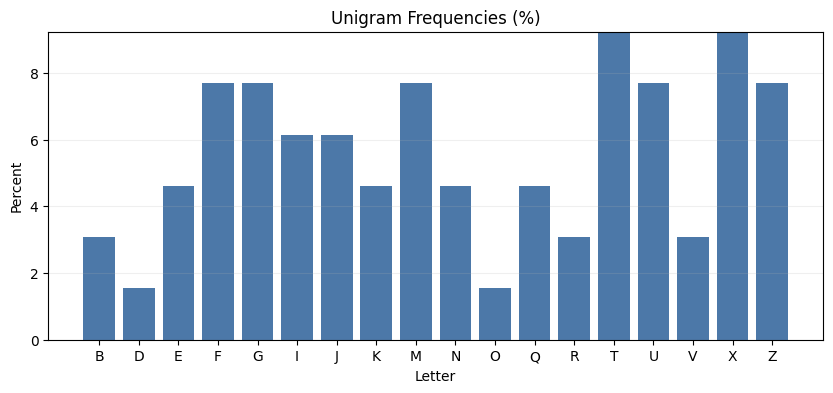

In [6]:
# Soal 3 Analisis Frekuensi
import re
import string
import pandas as pd
import matplotlib.pyplot as plt

def preprocess_text(text, merge_ij=False, remove_padding=None):
    t = re.sub(r'[^A-Za-z]', '', text).upper()
    if remove_padding in {'X', 'x'}:
        t = t.replace('X', '')
    if merge_ij:
        t = t.replace('J', 'I')
    return t

def frequency_table(text, merge_ij=False, remove_padding=None, decimals=2):
    t = preprocess_text(text, merge_ij=merge_ij, remove_padding=remove_padding)
    alphabet = list("ABCDEFGHIKLMNOPQRSTUVWXYZ") if merge_ij else list(string.ascii_uppercase)
    total = len(t)
    counts = {ch: 0 for ch in alphabet}
    for ch in t:
        if ch in counts:
            counts[ch] += 1
    df = pd.DataFrame({
        'Letter': alphabet,
        'Count': [counts[ch] for ch in alphabet]
    })
    df['Percent'] = (df['Count'] / total * 100).round(decimals) if total > 0 else 0
    df = df[df['Count'] > 0]  # ← Hapus huruf dengan frekuensi nol
    return df, total

def plot_frequencies(df, title='Unigram Frequencies (%)'):
    plt.figure(figsize=(10, 4))
    plt.bar(df['Letter'], df['Percent'], color='#4C78A8')
    plt.ylabel('Percent')
    plt.xlabel('Letter')
    plt.title(title)
    plt.ylim(0, max(df['Percent'].max(), 5))
    plt.grid(axis='y', alpha=0.2)
    plt.show()

# ===== Contoh pakai =====
ciphertext = """ZIT JX UFN ZIT VXFG QGMTR JXU BMEK ZIT OQFN
JXU ZDGMEK ZIT UFN BMEK JXU VXFG QGMTR"""

df, total = frequency_table(ciphertext, merge_ij=False, remove_padding=None, decimals=2)
print(f"Total letters analyzed: {total}")
display(df)
plot_frequencies(df, title='Unigram Frequencies (%)')




Total letters analyzed: 65


,Letter,Count,Percent
1,B,2,3.08
3,D,1,1.54
4,E,3,4.62
5,F,5,7.69
6,G,5,7.69
8,I,4,6.15
9,J,4,6.15
10,K,3,4.62
12,M,5,7.69
13,N,3,4.62


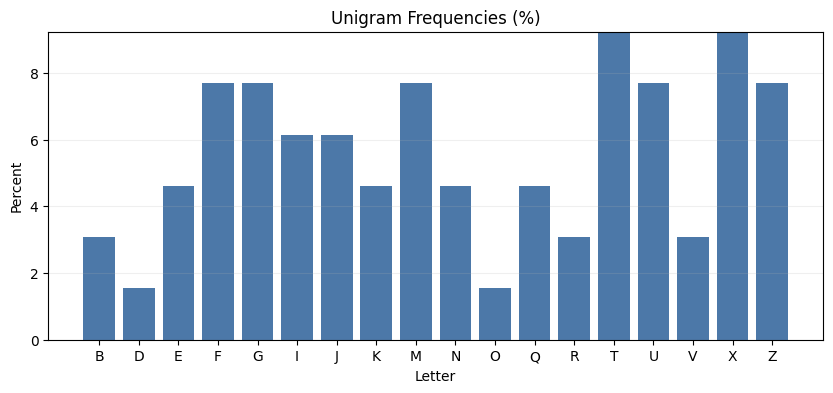


Substitusi parsial (seed THE & AND):
THE AN D?? THE ?N?? ???E? AND ???? THE ????
AND T????? THE D?? ???? AND ?N?? ???E?


In [9]:
# Soal 3 Analisis Frekuensi
import re
import string
import pandas as pd
import matplotlib.pyplot as plt

def preprocess_text(text, merge_ij=False, remove_padding=None):
    t = re.sub(r'[^A-Za-z]', '', text).upper()
    if remove_padding in {'X', 'x'}:
        t = t.replace('X', '')
    if merge_ij:
        t = t.replace('J', 'I')
    return t

def frequency_table(text, merge_ij=False, remove_padding=None, decimals=2):
    t = preprocess_text(text, merge_ij=merge_ij, remove_padding=remove_padding)
    alphabet = list("ABCDEFGHIKLMNOPQRSTUVWXYZ") if merge_ij else list(string.ascii_uppercase)
    total = len(t)
    counts = {ch: 0 for ch in alphabet}
    for ch in t:
        if ch in counts:
            counts[ch] += 1
    df = pd.DataFrame({
        'Letter': alphabet,
        'Count': [counts[ch] for ch in alphabet]
    })
    df['Percent'] = (df['Count'] / total * 100).round(decimals) if total > 0 else 0
    df = df[df['Count'] > 0]  # Hapus huruf dengan frekuensi nol
    return df, total

def plot_frequencies(df, title='Unigram Frequencies (%)'):
    plt.figure(figsize=(10, 4))
    plt.bar(df['Letter'], df['Percent'], color='#4C78A8')
    plt.ylabel('Percent')
    plt.xlabel('Letter')
    plt.title(title)
    plt.ylim(0, max(df['Percent'].max(), 5))
    plt.grid(axis='y', alpha=0.2)
    plt.show()

# ===== Contoh pakai =====
ciphertext = """ZIT JX UFN ZIT VXFG QGMTR JXU BMEK ZIT OQFN
JXU ZDGMEK ZIT UFN BMEK JXU VXFG QGMTR"""

df, total = frequency_table(ciphertext, merge_ij=False, remove_padding=None, decimals=2)
print(f"Total letters analyzed: {total}")
display(df)
plot_frequencies(df, title='Unigram Frequencies (%)')

# ===== Substitusi parsial dengan seed mapping =====
# Berdasarkan pola umum bahasa Inggris:
# - Unigram: E, T, A, O, I, N adalah huruf umum
# - Bigram: TH, HE, AN, IN, ER sering muncul
# - Kata 3 huruf yang sering: THE, AND

# Dari ciphertext, kata berulang: ZIT, JXU
# Tebak kuat:
seed_map = {
    'Z':'T',  # ZIT -> THE
    'I':'H',
    'T':'E',
    'J':'A',  # JXU -> AND
    'X':'N',
    'U':'D'
}

def apply_partial_map(ct, mapping):
    out = []
    for c in ct:
        if c in string.ascii_uppercase:
            out.append(mapping.get(c, '?'))
        else:
            out.append(c)
    return "".join(out)

print("\nSubstitusi parsial (seed THE & AND):")
print(apply_partial_map(ciphertext, seed_map))

In [10]:
# Soal 4 OTP Key Recovery
def otp_key_recovery(ciphertext, plaintext):
    def to_num(c): return ord(c.upper()) - 65
    def to_char(n): return chr(n + 65)

    C = [to_num(c) for c in ciphertext]
    P = [to_num(p) for p in plaintext]
    K = [(c - p) % 26 for c, p in zip(C, P)]
    key_chars = [to_char(k) for k in K]

    import pandas as pd
    df = pd.DataFrame({
        'Pos': list(range(1, len(C)+1)),
        'C': list(ciphertext),
        'C→Angka': C,
        'P': list(plaintext),
        'P→Angka': P,
        '(C - P) mod 26': K,
        'K': key_chars
    })
    return df, ''.join(key_chars)

ciphertext = "TLCYKUMGDF"
plaintext = "MRJOHNSONL"
df, key = otp_key_recovery(ciphertext, plaintext)
display(df)
print("Kunci akhir:", key)

,Pos,C,C→Angka,P,P→Angka,(C - P) mod 26,K
0,1,T,19,M,12,7,H
1,2,L,11,R,17,20,U
2,3,C,2,J,9,19,T
3,4,Y,24,O,14,10,K
4,5,K,10,H,7,3,D
5,6,U,20,N,13,7,H
6,7,M,12,S,18,20,U
7,8,G,6,O,14,18,S
8,9,D,3,N,13,16,Q
9,10,F,5,L,11,20,U


Kunci akhir: HUTKDHUSQU
